In [1]:
import pandas as pd
# ── Chargement ────────────────────────────────────────────────────────────────
df = pd.read_csv('../6.Data/kaggle_b2_fraud_train_v4.csv')



#COLONE CATEGORIQUE CHOISIT
COLONE = 'is_vpn'

#Pour sauvegarder les graphiques , activer saves dans la fonction plot_donut_for_value
df[[COLONE, 'target_is_fraud']].target_is_fraud.value_counts()

target_is_fraud
0    146223
1     13777
Name: count, dtype: int64

📊 2 valeur(s) unique(s) dans 'is_vpn' : [np.int64(0), np.int64(1)]



C:\Users\yannc\AppData\Local\Temp\ipykernel_12576\4111703545.py:73: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\yannc\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


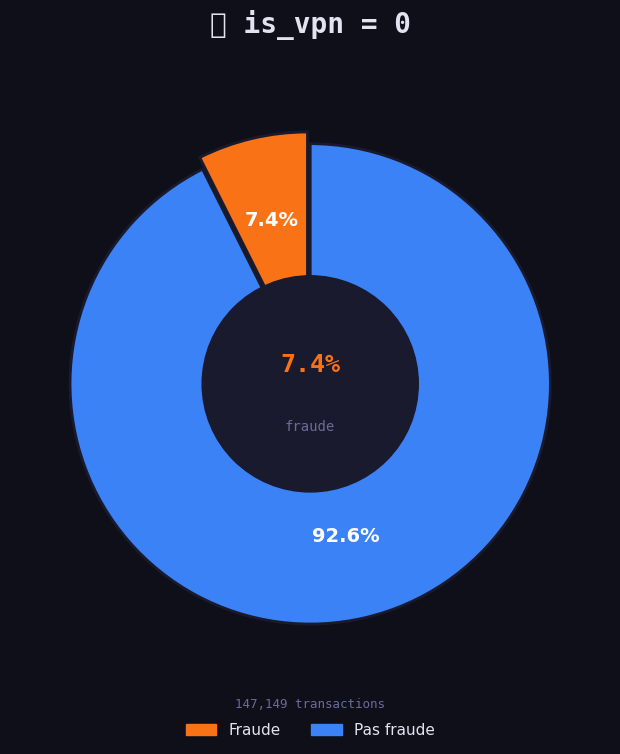

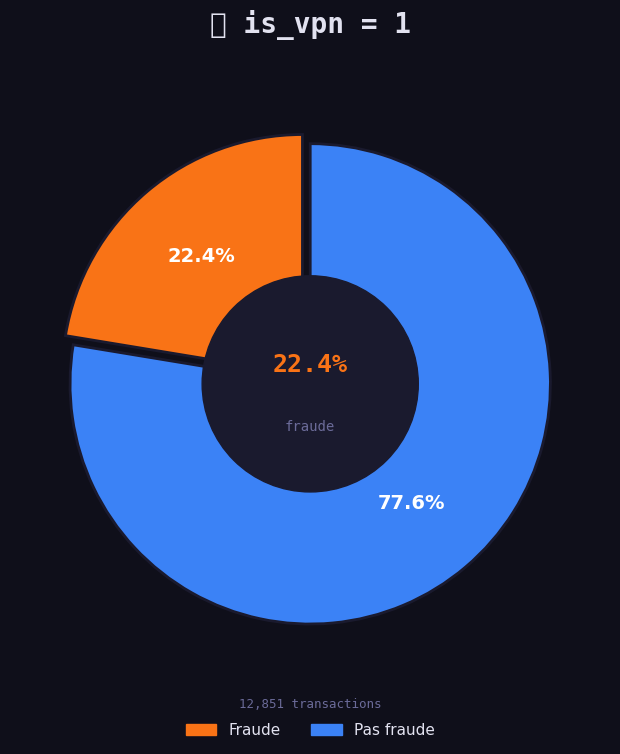

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np



# ── Couleurs ──
FRAUD_COLOR = "#f97316"
LEGIT_COLOR = "#3b82f6"
BG_COLOR    = "#0f0f1a"
CARD_COLOR  = "#1a1a2e"
TEXT_COLOR  = "#e2e2f0"
MUTED_COLOR = "#6b6b99"

def plot_donut_for_value(col_value, group_df, col_name, save=False):
    total = len(group_df)
    fraud = group_df["target_is_fraud"].sum()
    pct_fraud = round(fraud / total * 100, 1)
    pct_legit = round((total - fraud) / total * 100, 1)

    fig, ax = plt.subplots(figsize=(7, 7), facecolor=BG_COLOR)
    fig.suptitle(
        f"🔍 {col_name} = {col_value}",
        fontsize=20, fontweight="bold",
        color=TEXT_COLOR, y=1.02, fontfamily="monospace"
    )

    ax.set_facecolor(CARD_COLOR)
    for spine in ax.spines.values():
        spine.set_visible(False)

    sizes  = [pct_fraud, pct_legit]
    colors = [FRAUD_COLOR, LEGIT_COLOR]

    wedges, texts, autotexts = ax.pie(
        sizes,
        colors=colors,
        explode=(0.05, 0),
        autopct="%1.1f%%",
        startangle=90,
        pctdistance=0.65,
        wedgeprops=dict(linewidth=2, edgecolor=CARD_COLOR),
    )
    for at in autotexts:
        at.set_fontsize(14)
        at.set_fontweight("bold")
        at.set_color("white")

    # Trou central (donut)
    centre = plt.Circle((0, 0), 0.45, color=CARD_COLOR)
    ax.add_patch(centre)

    # Texte centre
    ax.text(0, 0.08, f"{pct_fraud:.1f}%", ha="center", va="center",
            fontsize=18, fontweight="bold", color=FRAUD_COLOR, fontfamily="monospace")
    ax.text(0, -0.18, "fraude", ha="center", va="center",
            fontsize=10, color=MUTED_COLOR, fontfamily="monospace")

    ax.text(0, -1.35, f"{int(total):,} transactions",
            ha="center", fontsize=9, color=MUTED_COLOR, fontfamily="monospace",
            transform=ax.transData)

    # Légende
    legend_patches = [
        mpatches.Patch(color=FRAUD_COLOR, label="Fraude"),
        mpatches.Patch(color=LEGIT_COLOR, label="Pas fraude"),
    ]
    fig.legend(handles=legend_patches, loc="lower center", ncol=2,
               frameon=False, fontsize=11,
               labelcolor=TEXT_COLOR, bbox_to_anchor=(0.5, -0.04))

    plt.tight_layout()

    if save:
        filename = f"fraud_chart_{col_name}_{col_value}.png"
        plt.savefig(filename, dpi=150, bbox_inches="tight", facecolor=BG_COLOR)
        print(f"✅ Sauvegardé : {filename}")

    plt.show()
    plt.close()


# ── Boucle sur toutes les valeurs uniques de COLONE ──
unique_values = df[COLONE].dropna().unique()
print(f"📊 {len(unique_values)} valeur(s) unique(s) dans '{COLONE}' : {list(unique_values)}\n")

for val in sorted(unique_values):
    subset = df[df[COLONE] == val]
    plot_donut_for_value(col_value=val, group_df=subset, col_name=COLONE)